## Nichtlineare Ausgleichsrechnung, Gauss-Newton und Levenberg-Marquardt
Ein nichtlineares Ausgleichsproblem ist ein Minimierungsproblem

$$
    |\vec{f}(\vec{p})|^2 \stackrel!= \textrm{min}
$$

für eine Funktion $\vec{f}:\mathbb{R}^n \to \mathbb{R}^{N}$. 

### Gauss-Newton Verfahren
Das **Gauss-Newton**-Verfahren ist sehr ähnlich, wie das Newtonverfahren für Gleichungssysteme:
  
* Wähle Startwerte $\vec{p}$
* Für $k = 1, 2, \ldots$
    * Löse das lineare Ausgleichsproblem $|\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 \to \textrm{min}$
    * Setze $\vec{p} := \vec{p} + \vec{\delta}$

$J$ bezeichnet die Jacobimatrix von $\vec{f}$ an der Stelle $\vec{p}$.

Genau wie das Gaussverfahren, kann Gauss-Newton konvergieren oder auch nicht, ahängig von der konkreten Aufgabe und dem Startwert $\vec{p}$. Die Idee dahinter ist, dass

$$
    \vec{f}(\vec{p} + \vec{\delta}) \approx \vec{f}(\vec{p}) + J \vec{\delta}
$$

### Levenberg-Marquardt Verfahren
Das **Levenberg-Marquardt** Verfahren ist eine Erweiterung von Gauss-Newton mit dem Ziel, robustere Konvergenz zu erreichen.

* Wähle $0 < \beta_0 < \beta_1$. Diese Parameter bleiben während der Iteration konstant.
* Wähle Startwert $\vec{p}$ und $\mu > 0$
* Für $k = 1, 2, \ldots$
    * Löse das lineare Ausgleichsproblem $|\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 + \mu^2 |\vec{\delta}|^2 \to \textrm{min}$
    * Berechne $\rho$ (s. unten)
    * Falls $\rho < \beta_0$: setze $\mu := 2 \mu$ (und behalte $\vec{p}$, d.h. das berechnete $\delta$ wird verworfen)
    * Falls $\beta_0 \leq \rho < \beta_1$: setze $\vec{p} := \vec{p} + \vec{\delta}$ (und behalte $\mu$)
    * Falls $\beta_1 < \rho$: setze $\mu := \mu/2$ und $\vec{p} := \vec{p} + \vec{\delta}$   

Die Idee der Minimierung ist, die "Schrittweite" $|\delta|$ zu beschränken, indem der Zusatzterm $\mu^2 |\vec{\delta}|^2$ in die Minimierung einfliesst. Die Minimierung von 
$$
    |\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 + \mu^2 |\vec{\delta}|^2
$$
ist jeweils ein *lineares* Ausgleichsproblem und kann erzielt werden, indem an die Jacobimatrix $J$ eine skalierte Einheitsmatrix $\mu \cdot E$ und an $\vec{f}(\vec{p})$ ein Nullvektor passender Länge angehängt wird.
 
Die Berechnung von $\rho$ ist

$$
    \rho = \frac{|\vec{f}(\vec{p})|^2 - |\vec{f}(\vec{p} + \vec{\delta})|^2}{|\vec{f}(\vec{p})|^2 - |\vec{f}(\vec{p}) + J\, \vec{\delta}|^2}
$$

Hier ist die Idee, die echte Verbesserung (Zähler) mit der effektiv erreichten Verbesserung (Nenner) zu vergleichen 

# Aufgabe 1: Gauss-Newton
Implementieren Sie das **Gauss-Newton Verfahren** und testen Sie es an dem Modell
$$
    y_i = u_0 \cdot e^{- a t} \cdot \sin (\omega t + \varphi)
$$

mit den Parametern $(u_0, a, \omega, \varphi)$ mit den Daten, die von dem folgenden Abschnitt erzeugt werden. Wälen Sie Startwerte, die nicht zu weit von den echten Werten (s. Code) abweichen. Experimentieren Sie ein wenig mit den Konvergenzeigenschaften von Gauss-Newton.

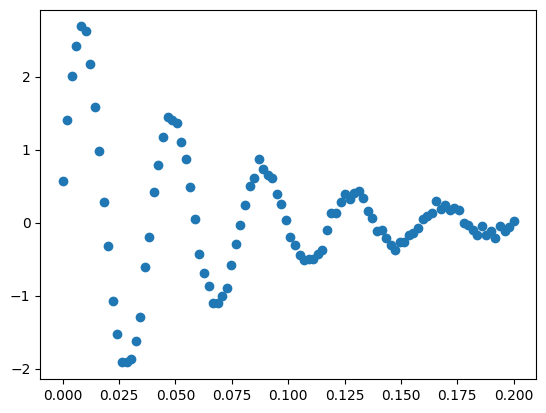

In [378]:
import numpy as np
import matplotlib.pyplot as plt

# Daten erzeugen mit den Parametern:
u0 = 3
a = 15
w = 25 * 2 * np.pi
phi = 10 * np.pi / 180

noiseAmp = 0.05 # Amplitude der Messfehler (kein Parameter des Modells)

N = 100
t = np.linspace(0, 5 * 2 * np.pi / w, 100)
y = u0 * np.exp(-a * t) * np.sin(w*t + phi) + noiseAmp * np.random.randn(N)

plt.scatter(t, y)

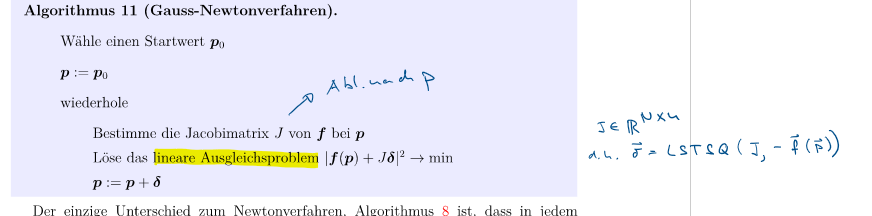

p     = [ 13.           2.         144.51326207   0.15707963] 	delta =  [11.67845898  1.18382964  9.00703896  0.18033892]
p     = [ 24.67845898   3.18382964 153.52030103   0.33741855] 	delta =  [-13.38080842  -0.31340682   4.55185225  -0.17653498]
p     = [ 11.29765056   2.87042282 158.07215328   0.16088358] 	delta =  [ 3.33232444  0.12327234 -0.68238785  0.00430952]
p     = [ 14.629975     2.99369516 157.38976543   0.1651931 ] 	delta =  [ 0.6668995   0.04052803 -0.32696249  0.00447676]
p     = [ 15.2968745    3.0342232  157.06280295   0.16966986] 	delta =  [ 4.89526374e-03  6.45035203e-05 -2.26302613e-02  4.27025643e-04]
p     = [ 15.30176977   3.0342877  157.04017268   0.17009688] 	delta =  [-6.59830937e-05 -7.84121345e-06 -2.38594826e-04  7.45870753e-06]
p     = [ 15.30170378   3.03427986 157.03993409   0.17010434] 	delta =  [ 7.39579339e-07  5.14996138e-08 -2.14686922e-06  6.43301794e-08]
p     = [ 15.30170452   3.03427991 157.03993194   0.17010441] 	delta =  [-7.20268876e-09 -9.13

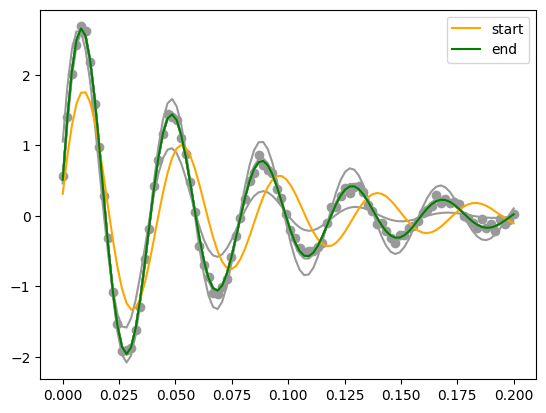

In [379]:
# Startwerte 
# ähnlich wie die paramter, einfach ein paar zahlen anderst damit man den unterschied gut sieht
u0 = 2
a = 13
w = 23 * 2 * np.pi
phi = 9 * np.pi / 180


p0 = np.array([a, u0, w, phi]) ## variablen (siehe aufgaben)
p = p0.copy() ##init


## funktion von oben:
f = lambda a, u0, w, phi: u0 * np.exp(-a * t) * np.sin(w*t + phi) 
## Jaccobi Matrix anhand f von oben:
J = lambda a, u0, w, phi: np.array([
    -t * u0 * np.exp(-a*t) * np.sin(w*t + phi),  # Ableitung nach a
    np.exp(-a*t) * np.sin(w*t + phi),            # Ableitung nach u0
    t * u0 * np.exp(-a*t) * np.cos(w*t + phi),   # Ableitung nach w
    u0 * np.exp(-a*t) * np.cos(w*t + phi)        # Ableitung nach phi
]).T


### kopiert aus beispiel, nichtlineare ausgleichsrechnung
from scipy.linalg import solve_triangular
## brauchen wir für gauss newton:
def lstsq(A, b):
    Q, R = np.linalg.qr(A)
    z = Q.T@b
    return solve_triangular(R, z)

for k in range(10):
    delta = lstsq(J(*p), y-f(*p)) # das Modell wäre f(p) - y = 0 -> Ausgleichsproblem: min J*d + (f(p) - y)
    print("p     =", p, "\tdelta = ", delta)
    p += delta
    plt.plot(t, f(*p), color = [.6,.6,.6])



plt.scatter(t, y, color = [.6,.6,.6])
plt.plot(t, f(*p0), color = "orange", label = "start") # Startwerte
plt.plot(t, f(*p), color = "green", label = "end")     # Nach Iteration

plt.legend()



# Aufgabe 2: Levenberg-Marquardt 
Implementieren Sie das **Levenberg-Marquardt Verfahren** und verwenden Sie dieses zur Bestimmung der Parameter

$$
    \vec{p} = (p_0, \ldots, p_6)
$$

des Modells

$$
    y = p_0 + p_1 \cdot \omega + p_2 \cdot \omega^2 + p_3 \cdot \omega^3 + p_4 \cdot \ell(p_5, p_6, {\color{gray} \omega})
$$

mit 

$$
    \ell(p_5, p_6, {\color{gray} \omega}) = \frac{1}{1 + 4 \cdot \left( \frac{\omega - p_5}{p_6} \right)^2}
$$

und testen Sie dieses an den Daten im file dataP7.txt.  

Das Modell ist dasselbe, wie in Praktikum 5 (lineare Ausgleichsrechnung), aber es sind zwei zusätzliche Parameter hinzugekommen, die in P5 als bekannt vorausgesetzt wurden. Das Modell ist immer noch linear in den Parametern $p_0, \ldots, p_4$. Sie werden feststellen, dass diese in der Jacobimatrix gar nicht vorkommen. Ein Teil der Jacobimatrix entspricht der Matrix des linearen Ausgleichsproblem aus P5.

* Verwenden Sie die QR-Zerlegung aus P5 zur Lösung der linearen Ausgleichsprobleme
* Skalieren Sie die $\omega$-Achse!
* Tipp zur besseren Lesbarkeit: erstellen sie Hilfsfunktionen für die Funktion $\ell$ die den Peak darstellt sowie für die benötigten partiellen Ableitungen davon.
* Bestimmen Sie Startwerte, indem Sie die Modellfunktion plotten und mit den Daten vergleichen. Versuchen Sie nicht, die Startwerte allzu genau zu machen - schliesslich wollen Sie sehen, wie gut Levenberg-Marquardt mit mittelmässigen Startwerten zurecht kommt!

**Bemerkung**: Die Daten sind nicht exakt identisch mit den Daten aus P5

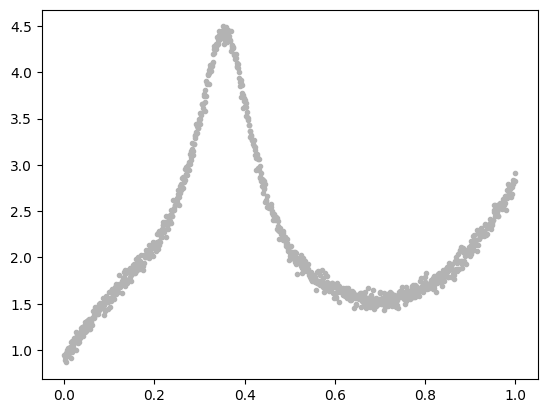

In [380]:
import numpy as np
import matplotlib.pyplot as plt 

data = np.genfromtxt("NUM1_Praktikum_W8_data.txt") ## namen angepasst
w, y = data.T

# Skalierung w, auf werte 0-1, da sie von 80000-81000 sind runternehmen
def scale(w):
    ws  = (w-80000) /1000
    return ws

w = scale(w)

plt.plot(w, y, '.', color = [.7,.7,.7]);

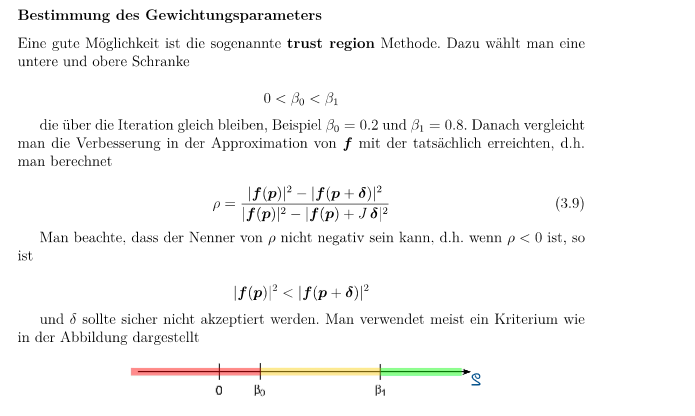

In [381]:
###---------------------------RHO FUNKTION-----------------------------------------
def rho(f, J, p, delta):
    r = y - f(*p)
    r_new = y - f(*(p + delta))
    r_lin = r - J(*p) @ delta
 
    return (np.linalg.norm(r)**2 - np.linalg.norm(r_new)**2) / \
           (1e-12 + np.linalg.norm(r)**2 - np.linalg.norm(r_lin)**2)
 

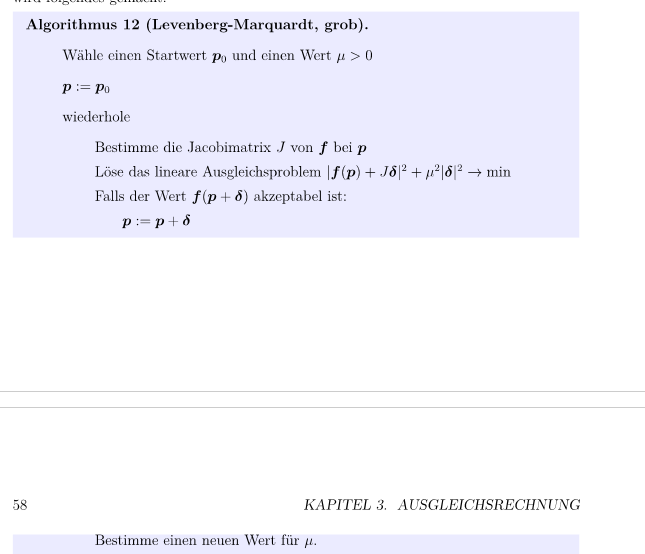

0 : f(p) =  67.76238 	 mu =  0.5 	 |delta| =  9.915597487462405 	 rho =  -0.2599664755069411
1 : f(p) =  67.76238 	 mu =  1.0 	 |delta| =  6.8997873727238375 	 rho =  0.033815396959178984
2 : f(p) =  67.76238 	 mu =  2.0 	 |delta| =  5.021109809637878 	 rho =  0.40219625116801366
3 : f(p) =  53.821 	 mu =  2.0 	 |delta| =  4.504675319363612 	 rho =  0.9999992145430362
4 : f(p) =  24.37967 	 mu =  1.0 	 |delta| =  5.468123983345119 	 rho =  0.9999935065553
5 : f(p) =  22.96038 	 mu =  0.5 	 |delta| =  9.05109425083939 	 rho =  1.0000031818715285
6 : f(p) =  20.90913 	 mu =  0.25 	 |delta| =  13.026213076928602 	 rho =  0.9999974965602013
7 : f(p) =  18.32552 	 mu =  0.125 	 |delta| =  14.643275301850172 	 rho =  0.9999580663576499
8 : f(p) =  16.16591 	 mu =  0.0625 	 |delta| =  11.4476412509664 	 rho =  0.9997288864038922
9 : f(p) =  15.23799 	 mu =  0.03125 	 |delta| =  5.561699015639998 	 rho =  0.997577446914682
10 : f(p) =  15.07495 	 mu =  0.015625 	 |delta| =  1.541567728023282 	

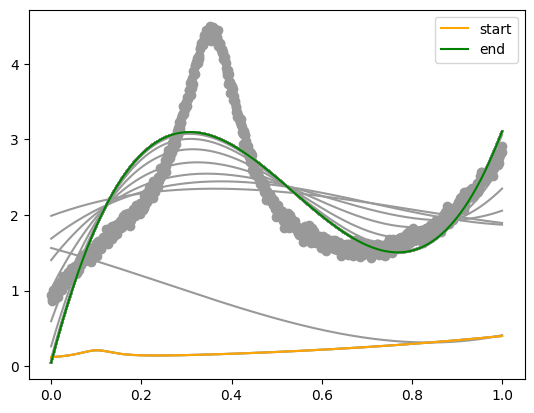

In [382]:
## startwerte definieren

p0 = 0.1
p1 = 0.1
p2 = 0.1
p3 = 0.1
p4 = 0.1
p5 = 0.1
p6 = 0.1

#startwerte
pStart = np.array([p0, p1, p2, p3, p4, p5, p6]) # Startwerte


# Hilfsfunktion L, nachher aufgerufen in F, definiert in aufgabenstellung
l = lambda p5, p6, w: 1 / (1 + 4 * ((w - p5) / p6)**2)

#f, definiert in aufgabenstellung
f = lambda p0, p1, p2, p3, p4, p5, p6: (
    p0 + p1*w + p2*w**2 + p3*w**3 + p4 * l(p5, p6, w)
)

# Jacobi-Matrix von f
J = lambda p0, p1, p2, p3, p4, p5, p6: np.array([
    np.ones_like(w),      # p0
    w,                    # p1
    w**2,                 # p2
    w**3,                 # p3
    l(p5, p6, w),         # p4
    p4 * (8 * (w - p5)**3 / p6**4) * l(p5, p6, w)**2, # Ableitung nach p5
    p4 * (8 * (w - p5)**4 / p6**5) * l(p5, p6, w)**2  # Ableitung nach p6
]).T


## übergebe P der Jaccobi:
#Je = lambda p0, p1, p2, p3, p4, p5, p6: J(*p)



## init
pLM = pStart.copy()
pStartCopy = pStart.copy()

##FUNKTION LM, aus beipsiel Lineare ausgleichsrechnung!!!
def LM(f, J, p, beta0 = 0.2, beta1 = 0.8, mu = 0.5, maxit = 100):

    n = len(p)
    delta = 1
    it = 0

    while np.linalg.norm(delta) > 1e-8 and it < maxit:
        
        Jext = np.concatenate( (J(*p), np.sqrt(mu) * np.eye(n)) )
        fext = np.concatenate ((y - f(*p), np.zeros(n)) ) # das Modell wäre f(p) - y = 0
        
        delta = lstsq(Jext, fext) # lineares Ausgleichsproblem lösen
        r = rho(f, J, p, delta)
    
        print(it, 
          ": f(p) = ", np.round(np.linalg.norm(y - f(*p)), 5), 
          "\t mu = ", mu, 
          "\t |delta| = ", np.linalg.norm(delta),
          "\t rho = ", r)

    
        if r < beta0:
            mu *= 2
        elif r < beta1:
            p += delta
        else:
            p += delta
            mu /= 2
    
        it += 1

        plt.plot(w, f(*p), color = [.6,.6,.6])

    return p

##- LOEWENBERG LANDQUARD AUFRUFEN
pLM = LM(f, J, pStart, maxit = 500)



##-------------------PLOT---------------------------------------------
plt.scatter(w, y, color = [.6,.6,.6])
plt.plot(w, f(*pStartCopy), color = "orange", label = "start") # mit Startwerten
plt.plot(w, f(*pLM), color = "green", label = "end")     # nach levenberg-Marquardt

plt.legend()

print("gefundene Parameter: ", pLM)